# grahspj: Mass retrieval test

The purpose of this Notebook is to examine the efficacy of the GRAHSPJ code for AGN mass retrieval

Workflow:
- load one deterministic example from the Chimera benchmark dataset
- build a `FitConfig`
- run a MAP fit
- compare recovered stellar mass to the Chimera truth value
- generate a `pcigale`-style component SED plot with the photometry overlaid

## Prerequisites

This notebook assumes:
- you are running it from the `grahsp-run-jax/notebooks` directory
- `grahspj` dependencies are installed
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.benchmark import (
    build_chimera_fit_config,
    load_chimera_benchmark_dataset,
    select_chimera_subset,
)
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/nicho/miniconda3/envs/astro/lib/python3.11/site-packages/dustmaps/config.py:74: ConfigWarning: Configuration file not found:

    /home/nicho/.dustmapsrc

To create a new configuration file in the default location, run the following python code:

    from dustmaps.config import config
    config.reset()

Note that this will delete your configuration! For example, if you have specified a data directory, then dustmaps will forget about its location.
  warn(('Configuration file not found:\n\n'


In [2]:
from astropy.io import fits
import numpy as np

chimera_dir = project_root / "data" / "chimeras-2023-10-11"
fullinfo_path = chimera_dir / "chimeras-fullinfo.fits"
dsps_ssp_fn = project_root / "tempdata.h5"

dataset = load_chimera_benchmark_dataset(project_root)
rows = list(dataset.rows)

with fits.open(fullinfo_path) as hdul:
    fullinfo = hdul[1].data

    lbol_lookup = {
        str(row["id"]): float(row["logLbol_QSO"])
        for row in fullinfo
        if np.isfinite(float(row["logLbol_QSO"]))
    }

rows_with_lbol = []

for row in rows:
    row = dict(row)
    row_id = str(row["id"])

    if row_id not in lbol_lookup:
        continue

    qso_weight = float(row["chimera_QSO_weight"])

    # Skip zero or negative QSO weights because log10(weight) is undefined.
    if not np.isfinite(qso_weight) or qso_weight <= 0:
        continue

    row["logLbol_QSO"] = lbol_lookup[row_id]

    # Effective AGN luminosity after CHIMERA QSO scaling.
    row["logLbol_chimera"] = row["logLbol_QSO"] + np.log10(qso_weight)

    rows_with_lbol.append(row)

print("Original rows:", len(rows))
print("Rows with effective CHIMERA AGN luminosity:", len(rows_with_lbol))

lbol_eff = np.array([r["logLbol_chimera"] for r in rows_with_lbol])

print("Min logLbol_chimera:", np.nanmin(lbol_eff))
print("Max logLbol_chimera:", np.nanmax(lbol_eff))
print("Percentiles:", np.nanpercentile(lbol_eff, [0, 1, 5, 16, 50, 84, 95, 99, 100]))

[benchmark] Loading Chimera photometry from /home/nicho/GRAHSP/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /home/nicho/GRAHSP/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
Original rows: 18168
Rows with effective CHIMERA AGN luminosity: 18159
Min logLbol_chimera: 40.650001525878906
Max logLbol_chimera: 48.29100036621094
Percentiles: [40.65000153 41.23258034 41.84012022 42.60100174 43.94800186 45.50699997
 46.48801135 47.17767937 48.29100037]


In [3]:
luminosity_bins = [
    ("L < 42", lambda L: L < 42),
    ("42 < L < 43", lambda L: (L >= 42) and (L < 43)),
    ("43 < L < 44", lambda L: (L >= 43) and (L < 44)),
    ("44 < L < 45", lambda L: (L >= 44) and (L < 45)),
]

rows_by_lbol = {}

for label, condition in luminosity_bins:
    selected = [
        r for r in rows_with_lbol
        if np.isfinite(float(r["logLbol_chimera"]))
        and condition(float(r["logLbol_chimera"]))
    ]
    rows_by_lbol[label] = selected
    print(label, ":", len(selected), "objects")

L < 42 : 1165 objects
42 < L < 43 : 3390 objects
43 < L < 44 : 4755 objects
44 < L < 45 : 4248 objects


In [4]:
N_PER_BIN = 5

rows_to_fit_by_bin = {
    label: selected[:N_PER_BIN]
    for label, selected in rows_by_lbol.items()
}

for label, selected in rows_to_fit_by_bin.items():
    print(label, len(selected))

L < 42 5
42 < L < 43 5
43 < L < 44 5
44 < L < 45 5


In [5]:
from pathlib import Path

files_to_delete = [
    project_root / "chimera_mass_retrieval_failures_partial.csv",
    project_root / "chimera_mass_retrieval_by_logLbol.csv",
]

for p in files_to_delete:
    if p.exists():
        p.unlink()
        print("Deleted:", p)
    else:
        print("Not found:", p)

Not found: /home/nicho/GRAHSP/grahspj/chimera_mass_retrieval_failures_partial.csv
Deleted: /home/nicho/GRAHSP/grahspj/chimera_mass_retrieval_by_logLbol.csv


In [6]:
def fit_one_chimera_row(
    row,
    dsps_ssp_fn,
    *,
    optax_steps=300,
    nuts_warmup=150,
    nuts_samples=150,
):
    cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))

    fitter = GRAHSPJ(cfg)

    fit_result = fitter.fit(
        fit_method="optax+nuts",
        prior_config=cfg.prior_config,
        dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
        optax_steps=optax_steps,
        optax_lr=1e-2,
        nuts_warmup=nuts_warmup,
        nuts_samples=nuts_samples,   # IMPORTANT: plural
        nuts_chains=1,
        plot_fig=False,
        save_fig=False,
        save_result=False,
        progress_bar=True,
    )

    logm_samples = np.asarray(
        fitter.samples["log_stellar_mass"],
        dtype=float,
    ).reshape(-1)

    logm16, recovered_logm, logm84 = np.percentile(
        logm_samples,
        [16.0, 50.0, 84.0],
    )

    truth_logm = float(row["log_stellar_mass_truth"])

    return {
        "object_id": str(row["id"]),
        "ID_COSMOS": row["ID_COSMOS"],
        "redshift": float(row["redshift"]),
        "truth_logm": truth_logm,
        "recovered_logm": float(recovered_logm),
        "logm16": float(logm16),
        "logm84": float(logm84),
        "residual_log_ratio": float(recovered_logm - truth_logm),
        "fit_result": fit_result,
    }

In [7]:
import pandas as pd
from pathlib import Path

partial_results_csv = project_root / "chimera_mass_retrieval_by_logLbol_partial.csv"
partial_failures_csv = project_root / "chimera_mass_retrieval_failures_partial.csv"
final_results_csv = project_root / "chimera_mass_retrieval_by_logLbol.csv"

# ------------------------------------------------------------
# Recover previous partial results if they exist
# ------------------------------------------------------------

if partial_results_csv.exists():
    previous_results_df = pd.read_csv(partial_results_csv)
    completed_ids = set(previous_results_df["object_id"].astype(str))
    all_results = previous_results_df.to_dict("records")
    print(f"Recovered {len(all_results)} previous successful fits.")
else:
    completed_ids = set()
    all_results = []
    print("No previous successful-fit file found. Starting fresh.")

if partial_failures_csv.exists():
    previous_failures_df = pd.read_csv(partial_failures_csv)
    failed_ids = set(previous_failures_df["object_id"].astype(str))
    all_failures = previous_failures_df.to_dict("records")
    print(f"Recovered {len(all_failures)} previous failures.")
else:
    failed_ids = set()
    all_failures = []
    print("No previous failure file found.")

# Usually we skip both completed and failed objects when resuming.
skip_ids = completed_ids | failed_ids

# ------------------------------------------------------------
# Main fitting loop
# ------------------------------------------------------------

for bin_label, selected_rows in rows_to_fit_by_bin.items():
    print("\n" + "="*70, flush=True)
    print(f"Running luminosity bin: {bin_label}", flush=True)
    print(f"Number of objects: {len(selected_rows)}", flush=True)
    print("="*70, flush=True)

    for i, row in enumerate(selected_rows, start=1):
        object_id = str(row["id"])

        if object_id in skip_ids:
            print(f"Skipping already processed object: {object_id}", flush=True)
            continue

        print(
            f"\n[{bin_label}] Fitting {i}/{len(selected_rows)}: "
            f"id={row['id']}, ID_COSMOS={row['ID_COSMOS']}, "
            f"logLbol_QSO={row['logLbol_QSO']:.3f}, "
            f"logLbol_chimera={row['logLbol_chimera']:.3f}, "
            f"QSO_weight={row['chimera_QSO_weight']:.5g}",
            flush=True,
        )

        try:
            result = fit_one_chimera_row(
                row,
                dsps_ssp_fn,
                optax_steps=300,
                nuts_warmup=150,
                nuts_samples=150,
            )

            # Add metadata
            result["luminosity_bin"] = bin_label
            result["logLbol_QSO"] = float(row["logLbol_QSO"])
            result["logLbol_chimera"] = float(row["logLbol_chimera"])
            result["chimera_QSO_weight"] = float(row["chimera_QSO_weight"])

            # Make sure object_id is stored under a consistent name
            if "object_id" not in result:
                result["object_id"] = object_id

            all_results.append(result)
            skip_ids.add(object_id)

            print(
                "truth_logm =",
                result["truth_logm"],
                "recovered_logm =",
                result["recovered_logm"],
                "residual =",
                result["residual_log_ratio"],
                flush=True,
            )

            # ------------------------------------------------------------
            # SAVE IMMEDIATELY AFTER EACH SUCCESSFUL FIT
            # ------------------------------------------------------------
            results_df_partial = pd.DataFrame([
                {k: v for k, v in r.items() if k != "fit_result"}
                for r in all_results
            ])

            results_df_partial.to_csv(partial_results_csv, index=False)

            print(
                f"Saved partial results: {len(results_df_partial)} rows -> {partial_results_csv}",
                flush=True,
            )

        except Exception as e:
            print("FAILED:", row["id"], row["ID_COSMOS"], repr(e), flush=True)

            failure = {
                "luminosity_bin": bin_label,
                "object_id": object_id,
                "ID_COSMOS": row["ID_COSMOS"],
                "logLbol_QSO": float(row["logLbol_QSO"]),
                "logLbol_chimera": float(row["logLbol_chimera"]),
                "chimera_QSO_weight": float(row["chimera_QSO_weight"]),
                "error": repr(e),
            }

            all_failures.append(failure)
            skip_ids.add(object_id)

            # ------------------------------------------------------------
            # SAVE IMMEDIATELY AFTER EACH FAILURE TOO
            # ------------------------------------------------------------
            failures_df_partial = pd.DataFrame(all_failures)
            failures_df_partial.to_csv(partial_failures_csv, index=False)

            print(
                f"Saved partial failures: {len(failures_df_partial)} rows -> {partial_failures_csv}",
                flush=True,
            )

# ------------------------------------------------------------
# Final save
# ------------------------------------------------------------

results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fit_result"}
    for r in all_results
])

results_df.to_csv(final_results_csv, index=False)

print("\nCompleted fits:", len(results_df), flush=True)
print("Failures:", len(all_failures), flush=True)
print("Final saved:", final_results_csv, flush=True)

results_df

Recovered 160 previous successful fits.
No previous failure file found.

Running luminosity bin: L < 42
Number of objects: 5
Skipping already processed object: 013549.53+241149.7_243632_0.0001
Skipping already processed object: 014534.36+143136.9_532567_0.0001
Skipping already processed object: 014930.89+125129.4_664442_0.0001
Skipping already processed object: 015034.96+150249.5_730865_0.0001
Skipping already processed object: 015222.08+133415.4_810798_0.0001

Running luminosity bin: 42 < L < 43
Number of objects: 5
Skipping already processed object: 011529.24+321114.9_810483_0.001
Skipping already processed object: 011601.41+322234.8_623550_0.0003
Skipping already processed object: 011601.41+322234.8_678946_0.0003
Skipping already processed object: 011847.39+390428.1_367255_0.001
Skipping already processed object: 011847.39+390428.1_580679_0.0003

Running luminosity bin: 43 < L < 44
Number of objects: 5
Skipping already processed object: 011521.37+311730.6_386291_0.0003
Skipping alre

,object_id,ID_COSMOS,redshift,truth_logm,recovered_logm,logm16,logm84,residual_log_ratio,luminosity_bin,logLbol_QSO,logLbol_chimera,chimera_QSO_weight
0,013549.53+241149.7_243632_0.0001,243632,0.5290,8.33448,8.455808,8.136267,8.747242,0.121328,L < 42,45.759998,41.759998,0.0001
1,014534.36+143136.9_532567_0.0001,532567,0.6320,8.23273,8.650240,8.167263,8.779809,0.417510,L < 42,45.710999,41.710999,0.0001
2,014930.89+125129.4_664442_0.0001,664442,0.8461,8.49398,8.467246,8.237939,8.707508,-0.026734,L < 42,45.923000,41.923000,0.0001
3,015034.96+150249.5_730865_0.0001,730865,0.4295,10.74990,10.762687,10.710395,10.786541,0.012787,L < 42,45.271999,41.271999,0.0001
4,015222.08+133415.4_810798_0.0001,810798,0.3700,7.41708,7.720865,7.426926,7.939759,0.303785,L < 42,45.400002,41.400002,0.0001
...,...,...,...,...,...,...,...,...,...,...,...,...
155,021249.47+003448.6_492725_0.01,492725,1.2170,9.33452,10.014280,9.547080,10.124032,0.679760,44 < L < 45,46.133999,44.133999,0.0100
156,021249.47+003448.6_540552_0.03,540552,1.2220,9.87085,10.545386,10.300398,10.678066,0.674536,44 < L < 45,46.133999,44.611120,0.0300
157,021249.47+003448.6_636396_0.01,636396,1.2229,8.92347,9.555379,9.297419,9.936894,0.631909,44 < L < 45,46.133999,44.133999,0.0100
158,021249.47+003448.6_763605_0.01,763605,1.2190,9.42117,10.136278,10.055232,10.229714,0.715108,44 < L < 45,46.133999,44.133999,0.0100


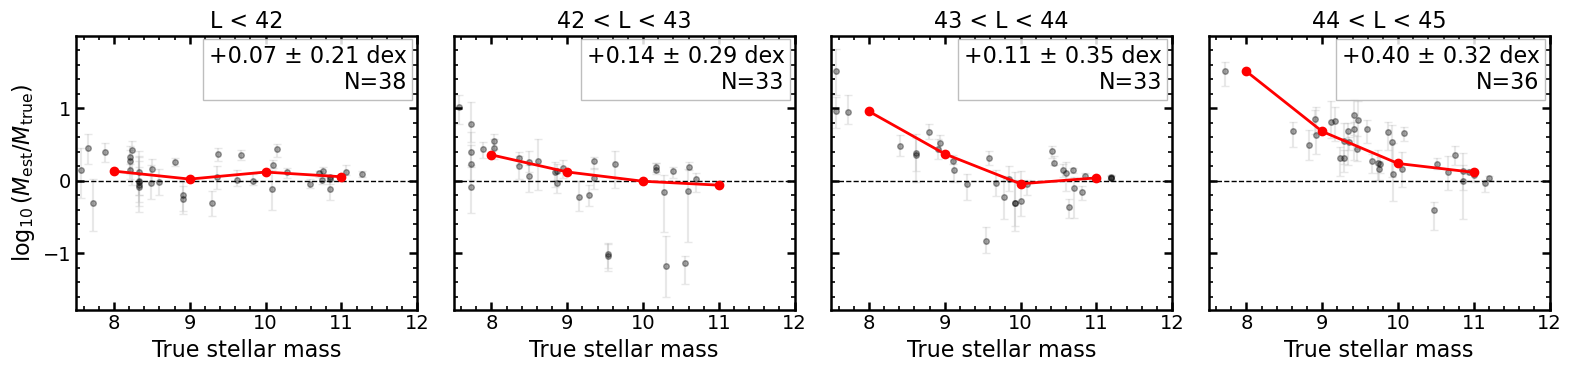

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

bin_order = ["L < 42", "42 < L < 43", "43 < L < 44", "44 < L < 45"]

# Red-line points exactly at integer stellar masses.
# Each point uses a bin centered on that integer:
# x=8 uses 7.5 <= logM < 8.5
# x=9 uses 8.5 <= logM < 9.5
# x=10 uses 9.5 <= logM < 10.5
# x=11 uses 10.5 <= logM < 11.5
mass_centers = np.array([8, 9, 10, 11])

for ax, label in zip(axes, bin_order):
    df = results_df[results_df["luminosity_bin"] == label]

    ax.axhline(0.0, color="black", ls="--", lw=1.0)

    if len(df) == 0:
        ax.set_title(f"{label}\nN=0")
        ax.set_xlim(7.5, 12)
        ax.set_xlabel(r"True stellar mass $\log_{10}(M_{\rm true}/M_\odot)$")
        continue

    x = df["truth_logm"].to_numpy()
    y = df["residual_log_ratio"].to_numpy()

    yerr_lower = df["recovered_logm"].to_numpy() - df["logm16"].to_numpy()
    yerr_upper = df["logm84"].to_numpy() - df["recovered_logm"].to_numpy()

    # Keep individual points down to x = 7.5
    keep = x >= 7.5
    x = x[keep]
    y = y[keep]
    yerr_lower = yerr_lower[keep]
    yerr_upper = yerr_upper[keep]

    # Individual fitted objects
    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="o",
        capsize=3,
        ms=4,
        alpha=0.35,
        color="black",
        ecolor="0.75",
        zorder=1,
    )

    # Red binned trend line only at x = 8, 9, 10, 11
    red_x = []
    red_y = []

    for center in mass_centers:
        lo = center - 0.5
        hi = center + 0.5

        mask = (x >= lo) & (x < hi)

        if np.sum(mask) == 0:
            continue

        red_x.append(center)
        red_y.append(np.nanmedian(y[mask]))

    ax.plot(
        red_x,
        red_y,
        "-o",
        color="red",
        lw=2.0,
        ms=6,
        zorder=5,
    )

    bias = np.nanmedian(y)
    scatter = 0.5 * (np.nanpercentile(y, 84) - np.nanpercentile(y, 16))

    ax.text(
        0.97,
        0.97,
        f"{bias:+.2f} ± {scatter:.2f} dex\nN={len(y)}",
        transform=ax.transAxes,
        va="top",
        ha="right",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
    )

    ax.set_title(label)
    ax.set_xlim(7.5, 12)
    ax.set_xlabel(r"True stellar mass")

axes[0].set_ylabel(r"$\log_{10}(M_{\rm est}/M_{\rm true})$")

plt.tight_layout()
plt.show()